In [2]:
import cv2
from skimage.util import random_noise
import numpy as np
from matplotlib import pyplot as plt

121 108 200


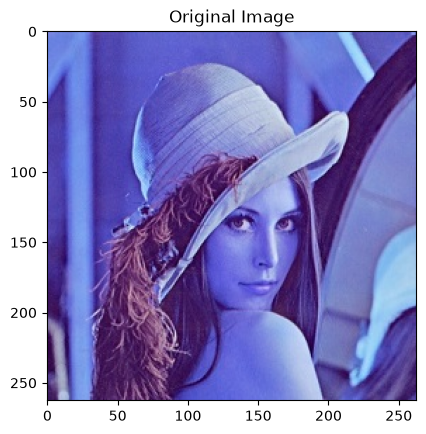

In [4]:
# ====================读取原始图像=====================
img = cv2.imread('lena.jpg')
# 获取图像中【100，100】这个像素的rbg三⾊
(b, g, r) = img[100, 100]
# 打印这个像素点的rbg参数
print(b, g, r)
# 输出原始图像
plt.imshow(img)
plt.title('Original Image')
plt.savefig('output_images/original_bgr.jpg', dpi=300)
plt.show()

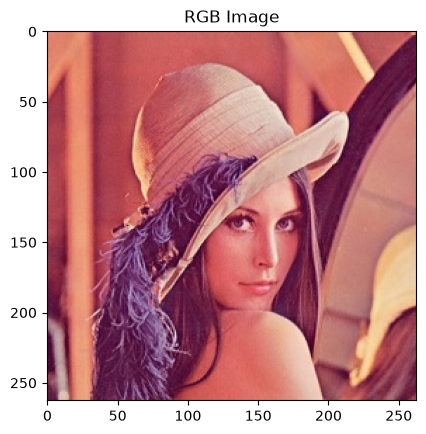

In [5]:
# 颜⾊空间转换，将原始图像BGR格式 转换成 RGB格式，蓝⾊和红⾊互换，因为把'B'和
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img)
plt.title('RGB Image')
plt.savefig('output_images/rgb_image.jpg', dpi=300)
plt.show()

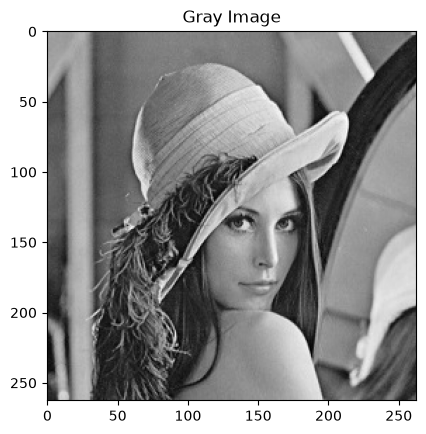

In [6]:
# 将原始图像的RBG格式转换为灰度图
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')
plt.title('Gray Image')
plt.savefig('output_images/gray_image.jpg', dpi=300)
plt.show()

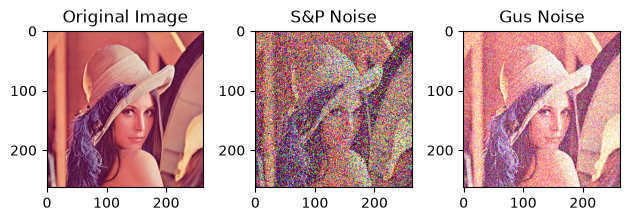

In [7]:
# ==========================添加噪声=========================
# mode='s&p'代表椒盐噪声，s代表⽩⾊，p代表⿊⾊，amount=0.4代表会有40%的像素
sp_noise_img = random_noise(rgb_img, mode='s&p', amount=0.4)
# mode='gaussian' 代表⾼斯噪声，会在每个像素上添加随机偏差，服从⾼斯分布（均值
gus_noise_img = random_noise(rgb_img, mode='gaussian', mean=0.2, var=0.03)
# 原图
plt.subplot(1, 3, 1)
plt.imshow(rgb_img, cmap='gray')
plt.title('Original Image')
# 椒盐噪声
plt.subplot(1, 3, 2)
plt.imshow(sp_noise_img, cmap='gray')
plt.title('S&P Noise')
# ⾼斯噪声
plt.subplot(1, 3, 3)
plt.imshow(gus_noise_img, cmap='gray')
plt.title('Gus Noise')
plt.tight_layout()
plt.savefig('output_images/noise_comparison.jpg', dpi=300)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14229246657124106..1.0000000000000007].


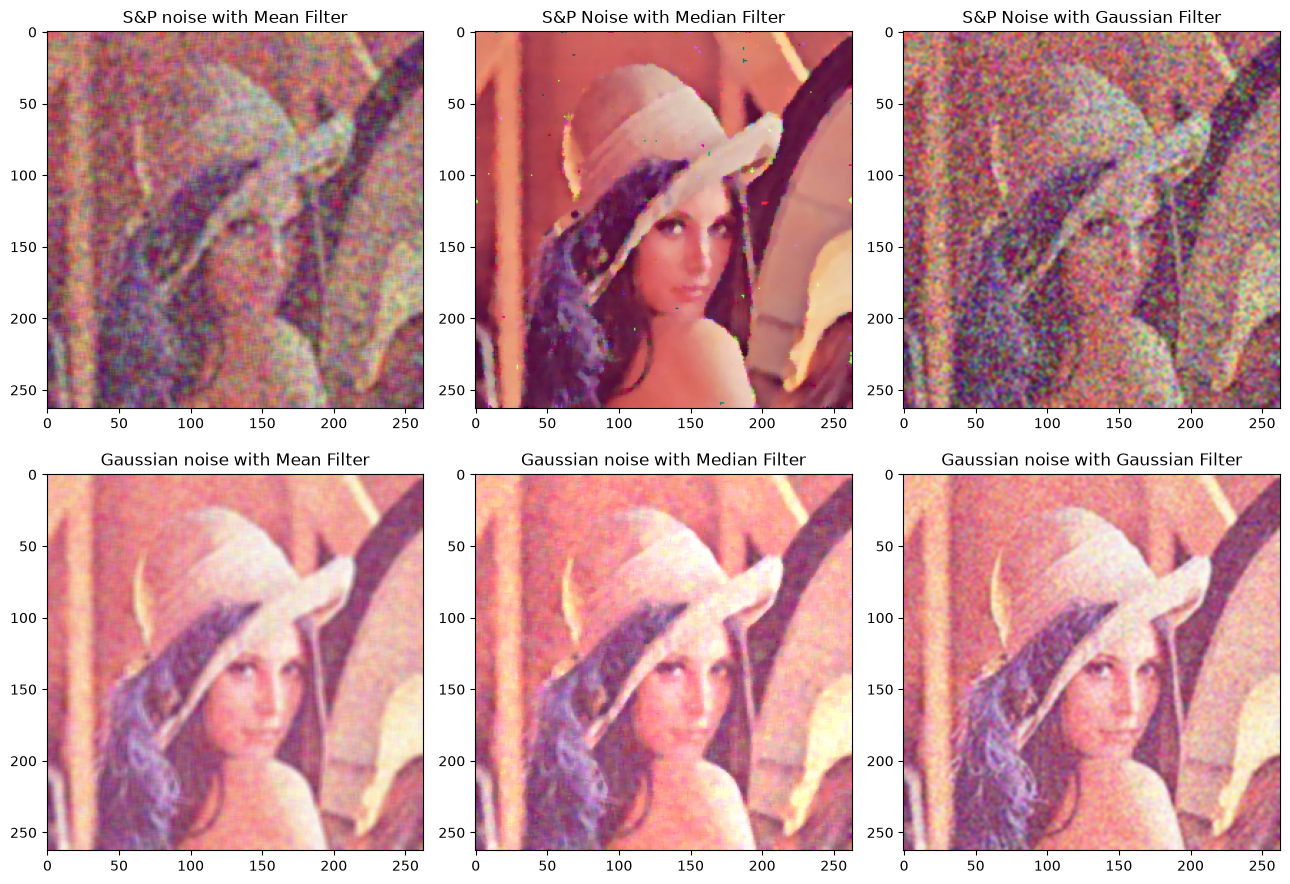

In [9]:
# =========================图像滤波=============================
# 均值滤波
mean_sp = cv2.blur(sp_noise_img, (5, 5))
mean_gus = cv2.blur(gus_noise_img, (5, 5))
# 中值滤波（需要 uint8）
mid_sp = cv2.medianBlur((sp_noise_img*255).astype(np.uint8), 5)
mid_gus = cv2.medianBlur((gus_noise_img*255).astype(np.uint8), 5)
# ⾼斯滤波
gauss_sp = cv2.GaussianBlur((sp_noise_img*255).astype(np.uint8), (5, 5), 0)
gauss_gus = cv2.GaussianBlur((gus_noise_img*255).astype(np.uint8), (5, 5), 0)
# 图像显⽰
plt.figure(figsize=(13, 9))
# 第1⾏：椒盐噪声
plt.subplot(2, 3, 1)
plt.imshow(mean_sp)
plt.title("S&P noise with Mean Filter")
plt.subplot(2, 3, 2)
plt.imshow(mid_sp)
plt.title("S&P Noise with Median Filter")
plt.subplot(2, 3, 3)
plt.imshow(gauss_sp)
plt.title("S&P Noise with Gaussian Filter")
# 第2⾏：⾼斯噪声
plt.subplot(2, 3, 4)
plt.imshow(mean_gus)
plt.title("Gaussian noise with Mean Filter")
plt.subplot(2, 3, 5)
plt.imshow(mid_gus)
plt.title("Gaussian noise with Median Filter")
plt.subplot(2, 3, 6)
plt.imshow(gauss_gus)
plt.title("Gaussian noise with Gaussian Filter")
plt.tight_layout()
plt.savefig('result/filter_results_2x3.jpg', dpi=300)
plt.show()

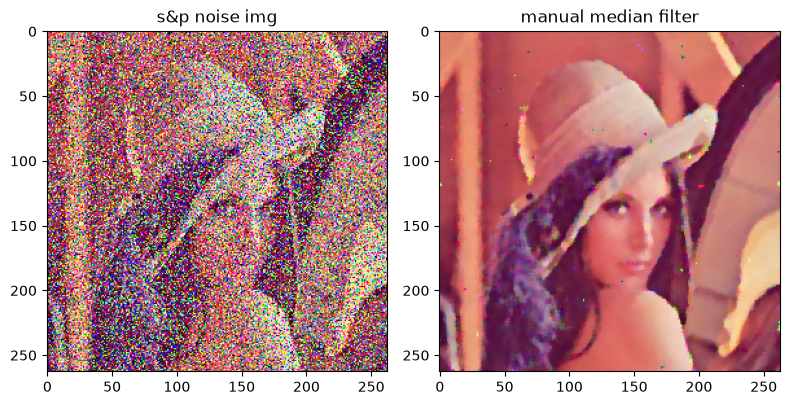

In [14]:
# ===========================⼿动实现中值滤波=========================
def manual_median_filter_color(image, kernel_size=5):
    """
        ⼿动实现彩⾊图像的中值滤波
        :param image: 输⼊彩⾊图像，numpy数组，shape=(H, W, 3)
        :param kernel_size: 滤波窗⼝⼤⼩
        :return: 中值滤波后的彩⾊图像
        """
    pad = kernel_size // 2
    # 对每个通道单独处理
    filtered_img = np.zeros_like(image)
    for c in range(3): # 遍历通道 R,G,B
        channel = image[:, :, c]
        padded_channel = np.pad(channel, pad_width=pad, mode='edge')
        for i in range(channel.shape[0]):
            for j in range(channel.shape[1]):
                region = padded_channel[i:i + kernel_size, j:j + kernel_size]
                filtered_img[i, j, c] = np.median(region)
    return filtered_img
# 对之前添加椒盐噪声的图像进⾏⼿动中值滤波
manual_mid = manual_median_filter_color((sp_noise_img * 255).astype(np.uint8), kernel_size=5)
# 显⽰对⽐
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sp_noise_img, cmap='gray')
plt.title("s&p noise img")
plt.subplot(1, 2, 2)
plt.imshow(manual_mid, cmap='gray')
plt.title("manual median filter")
plt.tight_layout()
plt.savefig('result/manual_median.jpg', dpi=300)
plt.show()

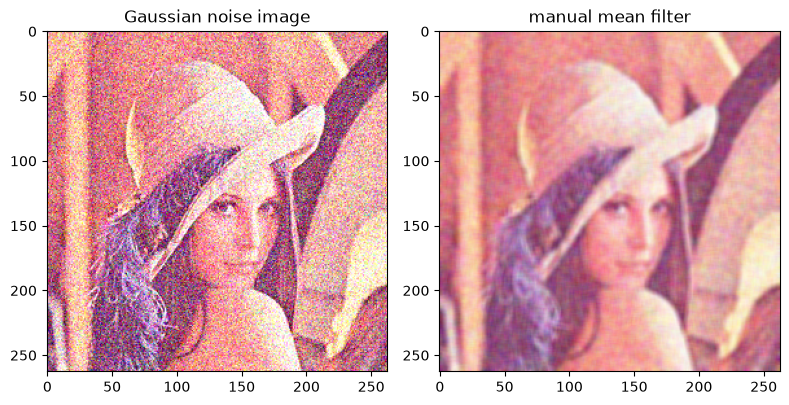

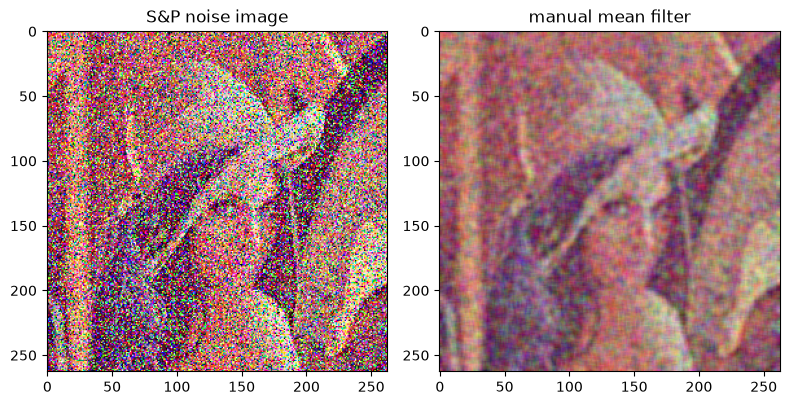

In [15]:
def manual_mean_filter_color(image, kernel_size=5):
    """
    手动实现彩色图像均值滤波
    :param image: 输入彩色uint8图像 (H,W,3)
    :param kernel_size: 卷积核窗口大小
    :return: 均值滤波后的彩色图像 uint8
    """
    pad = kernel_size // 2
    filtered_img = np.zeros_like(image, dtype=np.uint8)
    # 遍历R G B三个通道，分别滤波
    for c in range(3):
        channel = image[:, :, c]
        # edge模式：复制边缘像素填充，防止边界黑边
        padded_channel = np.pad(channel, pad_width=pad, mode='edge')
        h, w = channel.shape
        for i in range(h):
            for j in range(w):
                # 取出滑动窗口
                window = padded_channel[i:i+kernel_size, j:j+kernel_size]
                # 窗口求平均
                avg_val = np.mean(window)
                filtered_img[i, j, c] = avg_val
    return filtered_img

# 将高斯噪声图像转为uint8格式输入手动均值滤波
# 测试1：对高斯噪声图像做手动均值滤波
manual_mean_gauss = manual_mean_filter_color((gus_noise_img * 255).astype(np.uint8), kernel_size=5)
# 测试2：对椒盐噪声图像做手动均值滤波
manual_mean_sp = manual_mean_filter_color((sp_noise_img * 255).astype(np.uint8), kernel_size=5)

# 绘图对比：高斯噪声原图 vs 手动均值滤波结果
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gus_noise_img)
plt.title("Gaussian noise image")

plt.subplot(1,2,2)
plt.imshow(manual_mean_gauss)
plt.title("manual mean filter")
plt.tight_layout()
plt.savefig("result/manual_mean_gauss.jpg",dpi=300)
plt.show()

# 绘图对比：椒盐噪声原图 vs 手动均值滤波结果
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(sp_noise_img)
plt.title("S&P noise image")

plt.subplot(1,2,2)
plt.imshow(manual_mean_sp)
plt.title("manual mean filter")
plt.tight_layout()
plt.savefig("result/manual_mean_sp.jpg",dpi=300)
plt.show()